# Benchmarking the Skolem propagator against QuSpin

In [1]:
import os

threads = 16
os.environ['NUMEXPR_MAX_THREADS'] = '{}'.format(threads)
os.environ['NUMEXPR_NUM_THREADS'] = '{}'.format(threads)
os.environ['OMP_NUM_THREADS'] = '{}'.format(threads)
os.environ['MKL_NUM_THREADS'] = '{}'.format(threads)

In [2]:
import time
import numpy as np
from scipy.linalg import norm
import matplotlib.pyplot as plt

from quspin.operators import hamiltonian # Hamiltonians and operators
from quspin.basis import boson_basis_1d # Hilbert space boson basis

from skolem_propagator_bose_hubbard import BHSkolemPropagator

startTime = time.time()

## Parameters of the $K$ sites Bose Hubbard model and propagation

In [3]:
bh_params = dict(
    # On-sight interaction
    U = 1,
    
    # Hopping energy
    J = 1,
    
    # Chemical potential
    mu = 0,
    
    # Number of bosons
    N = 100,
    
    # Number of sites
    K = 4,
    
    # time-step
    dt = 0.01
)

times = bh_params['dt'] * np.arange(100)

##  QuSpin

Comparing the implementation of the Bose-Hubbard Model in the QuSpin library by following: https://github.com/weinbe58/QuSpin/blob/master/examples/notebooks/BHM.ipynb

In [4]:
def quspin_evolve(ψ0, times, *, U, J, N, K, mu, is_pbc, **kwargs):
    
    ##### construct Bose-Hubbard Hamiltonian #####
    # define boson basis with N states per site K bosons in the lattice

    basis = boson_basis_1d(K, Nb=N) # full boson basis

    # define site-coupling lists
    if is_pbc:
        # Peridodic bouundary condition
        hop=[[-J,i,(i+1)%K] for i in range(K)] 
    else:
        # open boundary condition
        hop=[[-J,i,(i+1)%K] for i in range(K - 1)]

    interact=[[0.5*U,i,i] for i in range(K)] # U/2 \sum_j n_j n_j
    pot=[[-mu-0.5*U,i] for i in range(K)] # -(\mu + U/2) \sum_j j_n

    # define static and dynamic lists
    static=[['+-',hop],['-+',hop],['n',pot],['nn',interact]]
    dynamic=[]

    # build Hamiltonian
    # old version     H =  hamiltonian(static,dynamic,basis=basis,dtype=np.float64)
    H =  hamiltonian(static,dynamic,basis=basis,check_symm=False,dtype=np.float64)
    
    return H.evolve(ψ0, times[0], times)

### Initialize Skolem propagator

In [5]:
t0 = time.time()

skolem_method = BHSkolemPropagator(**bh_params)

# Save time it took to initialize the Skolem propagator 
time_prepare_skolem = time.time() - t0

### Initial condition

In [6]:
ψ0 = np.zeros(skolem_method.indx.size, complex)
ψ0[0] = 1

## Open boundary condition

### QuSpin evolution

In [7]:
t0 = time.time()

Ψ_quspin_obc = quspin_evolve(ψ0, times, is_pbc=False, **bh_params)

print("QuSpin run time {:.1f} s".format(time.time() - t0))

Hermiticity check passed!
Particle conservation check passed!
QuSpin run time 190.7 s


### Skolem evolution

In [8]:
t0 = time.time()

Ψ_skolem_obc = [ψ0,]

for _ in times[1:]:
    Ψ_skolem_obc.append(
        skolem_method.propagate(Ψ_skolem_obc[-1], is_pbc=False)
    )
    
Ψ_skolem_obc = np.array(Ψ_skolem_obc).T

time_propagate_skolem = time.time() - t0

print("Preparation of basis and Skolem diagonalization: {:.1f} s".format(time_prepare_skolem))
print("Skolem propagation: {:.1f} s".format(time_propagate_skolem))

print("Total Skolem method run time {:.1f} s".format(time_prepare_skolem + time_propagate_skolem))

Preparation of basis and Skolem diagonalization: 4.6 s
Skolem propagation: 8.6 s
Total Skolem method run time 13.2 s


### Open boundary condition: Norm difference between QuSpin and Skolem propagator

In [9]:
tickFontSize = 15
axesNamefontSizes = 19
#plt.tick_params(axis='both', labelsize=tickFontSize)

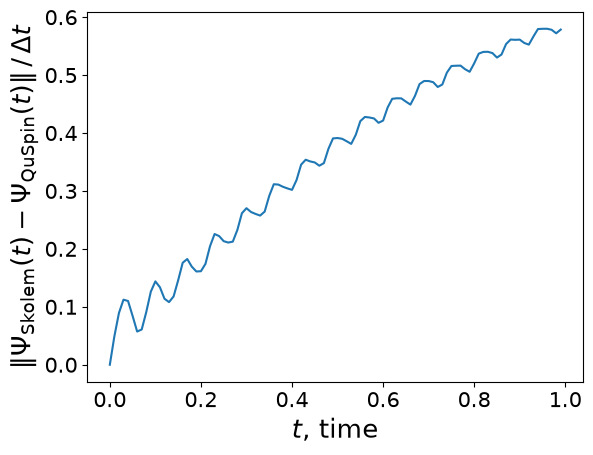

In [10]:
#plt.title("Norm difference between QuSpin and Skolem propagator")
plt.tick_params(axis='both', labelsize=tickFontSize)

plt.plot(times, norm(Ψ_skolem_obc - Ψ_quspin_obc, axis=0) / bh_params['dt'])
plt.xlabel("$t$, time", fontsize = axesNamefontSizes)
plt.ylabel(r"$\|\Psi_{\rm Skolem}(t) - \Psi_{\rm QuSpin}(t)\| \, / \, \Delta t$", fontsize = axesNamefontSizes)
plt.show()

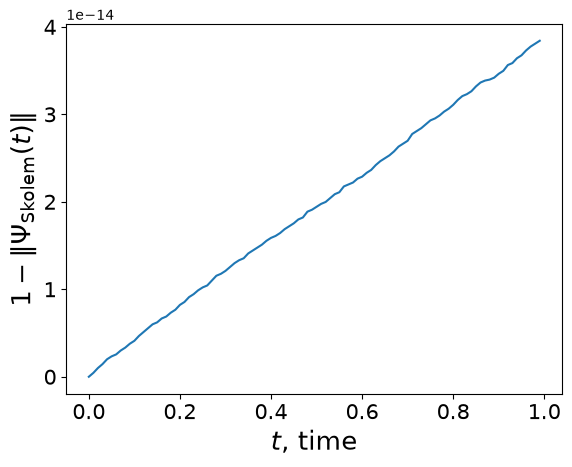

In [11]:
plt.tick_params(axis='both', labelsize=tickFontSize)

plt.plot(times, 1 - norm(Ψ_skolem_obc, axis=0))
plt.xlabel("$t$, time", fontsize = axesNamefontSizes)
plt.ylabel(r"$1 - \|\Psi_{\rm Skolem}(t) \|$", fontsize = axesNamefontSizes)
plt.show()

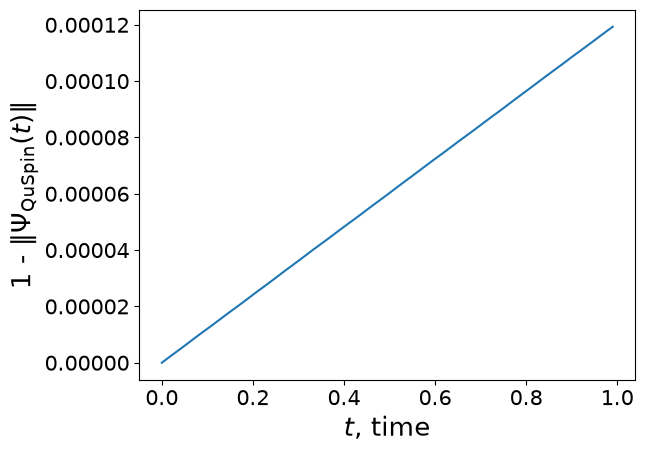

In [12]:
plt.tick_params(axis='both', labelsize=tickFontSize)
plt.plot(times, 1 - norm(Ψ_quspin_obc, axis=0))
plt.xlabel("$t$, time", fontsize = axesNamefontSizes)
plt.ylabel(r"1 - $\|\Psi_{\rm QuSpin}(t) \|$", fontsize = axesNamefontSizes)
plt.show()

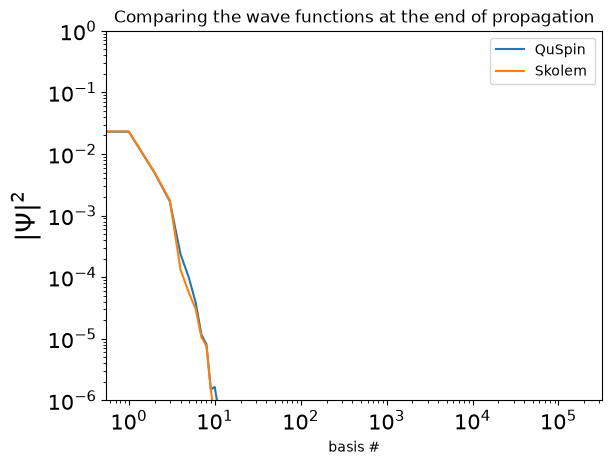

In [13]:
plt.tick_params(axis='both', labelsize=tickFontSize)
plt.title("Comparing the wave functions at the end of propagation")
plt.loglog(np.abs(Ψ_quspin_obc[:, -1]) ** 2, label='QuSpin ')
plt.loglog(np.abs(Ψ_skolem_obc[:, -1]) ** 2, label='Skolem')
plt.xlabel(r"basis #")
plt.ylabel(r"$|\Psi|^2$", fontsize = axesNamefontSizes)
plt.ylim([1e-6, 1e0,])
plt.legend()
plt.show()

## Periodic boundary condition

### QuSpin evolution

In [14]:
t0 = time.time()

Ψ_quspin_pbc = quspin_evolve(ψ0, times, is_pbc=True, **bh_params)

print("QuSpin run time {:.1f} s".format(time.time() - t0))

Hermiticity check passed!
Particle conservation check passed!
QuSpin run time 164.9 s


### Skolem evolution

In [15]:
t0 = time.time()

Ψ_skolem_pbc = [ψ0,]

for _ in times[1:]:
    Ψ_skolem_pbc.append(
        skolem_method.propagate(Ψ_skolem_pbc[-1], is_pbc=True)
    )
    
Ψ_skolem_pbc = np.array(Ψ_skolem_pbc).T

time_propagate_skolem = time.time() - t0

print("Preparation of basis and Skolem diagonalization: {:.1f} s".format(time_prepare_skolem))
print("Skolem propagation: {:.1f} s".format(time_propagate_skolem))

print("Total Skolem method run time {:.1f} s".format(time_prepare_skolem + time_propagate_skolem))

Preparation of basis and Skolem diagonalization: 4.6 s
Skolem propagation: 10.8 s
Total Skolem method run time 15.5 s


### Periodic boundary condition: Norm difference between QuSpin and Skolem propagator

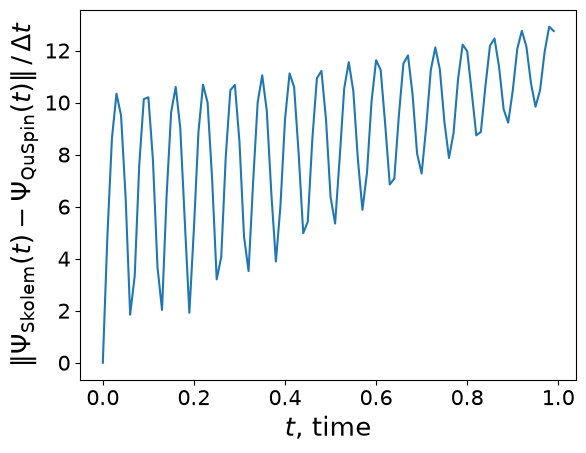

In [16]:
#plt.title("Norm difference between QuSpin and Skolem propagator")
plt.tick_params(axis='both', labelsize=tickFontSize)
plt.plot(times, norm(Ψ_skolem_pbc - Ψ_quspin_pbc, axis=0) / bh_params['dt'])
plt.xlabel("$t$, time", fontsize = axesNamefontSizes)
plt.ylabel(r"$\|\Psi_{\rm Skolem}(t) - \Psi_{\rm QuSpin}(t)\| \, / \, \Delta t$", fontsize = axesNamefontSizes)
plt.show()

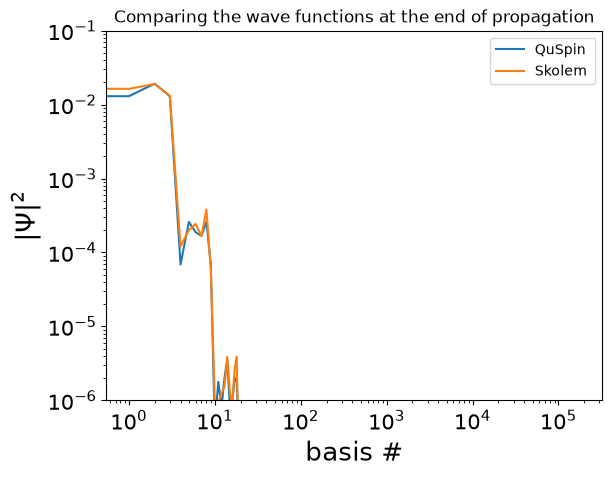

In [17]:
plt.tick_params(axis='both', labelsize=tickFontSize)
plt.title("Comparing the wave functions at the end of propagation")
plt.loglog(np.abs(Ψ_quspin_pbc[:, -1]) ** 2, label='QuSpin ')
plt.loglog(np.abs(Ψ_skolem_pbc[:, -1]) ** 2, label='Skolem')
plt.xlabel(r"basis #", fontsize = axesNamefontSizes)
plt.ylabel(r"$|\Psi|^2$", fontsize = axesNamefontSizes)
plt.ylim([1e-6, 1e-1,])
plt.legend()
plt.show()

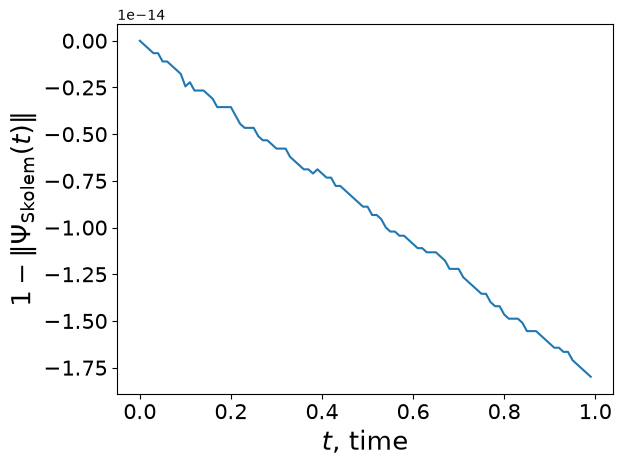

In [18]:
plt.tick_params(axis='both', labelsize=tickFontSize)
plt.plot(times, 1 - norm(Ψ_skolem_pbc, axis=0))
plt.xlabel("$t$, time", fontsize = axesNamefontSizes)
plt.ylabel(r"$1 - \|\Psi_{\rm Skolem}(t) \|$", fontsize = axesNamefontSizes)
plt.show()

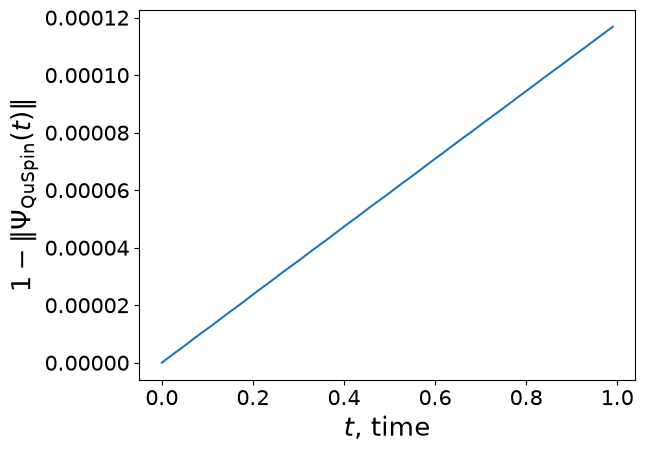

In [19]:
plt.tick_params(axis='both', labelsize=tickFontSize)
plt.plot(times, 1 - norm(Ψ_quspin_pbc, axis=0))
plt.xlabel("$t$, time", fontsize = axesNamefontSizes)
plt.ylabel(r"$1 - \|\Psi_{\rm QuSpin}(t) \|$", fontsize = axesNamefontSizes)
plt.show()

In [20]:
print("Total RUN time {:.1f} s".format(time.time() - startTime))

Total RUN time 383.3 s
